In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from mongoengine import connect
from mongoengine.errors import DoesNotExist
from django_app.models import Product, ProductCategory

load_dotenv()
connect(
    db="inventory_db",
    username=os.getenv("MONGO_USER", "root"),
    password=os.getenv("MONGO_PASS", "example"),
    host=os.getenv("MONGO_HOST", "localhost"),
    port=int(os.getenv("MONGO_PORT", "27019")),
    authentication_source="admin"
)
print("Connected to MongoDB successfully!")

Connected to MongoDB successfully!


In [8]:
products = Product.objects.all()

data = []
for p in products:
    try:
        category_title = p.category.title if p.category else "Uncategorized"
    except DoesNotExist:
        category_title = "Broken Reference"
        
    data.append({
        "Name": p.name,
        "Brand": p.brand,
        "Category": category_title,
        "Price": p.price,
        "Quantity": p.quantity
    })

df = pd.DataFrame(data)

df.head()

,Name,Brand,Category,Price,Quantity
0,Speaker,Hi,Electronics,20.0,6
1,Phone,MI,Electronics,100000.0,30
2,Keyboard,LI,Electronics,30.0,5


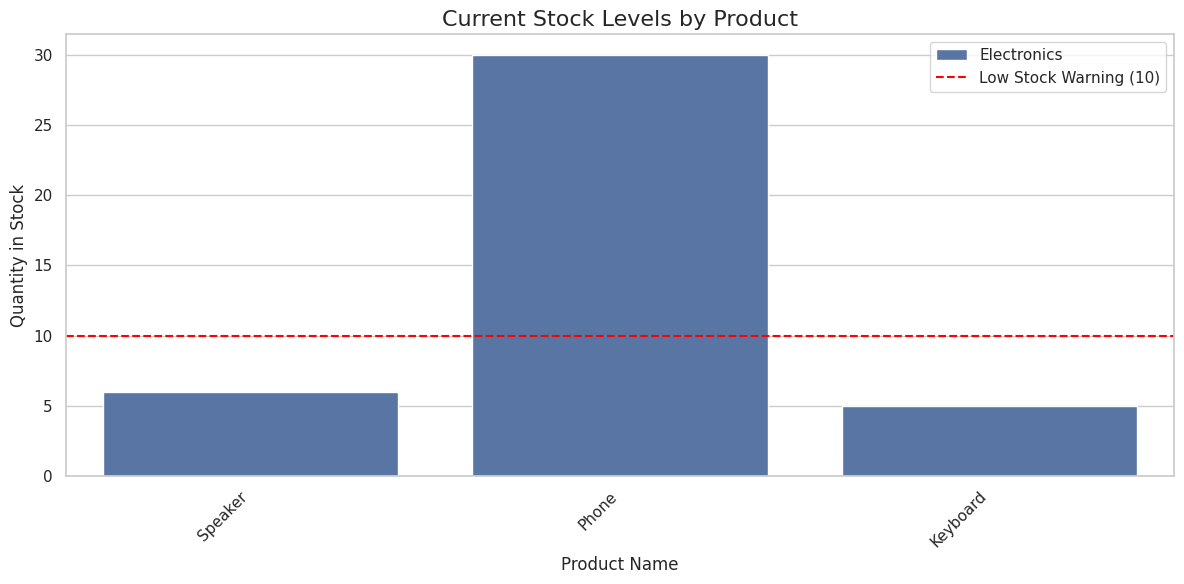

In [9]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

chart = sns.barplot(x="Name", y="Quantity", hue="Category", data=df, dodge=False)

plt.xticks(rotation=45, ha='right')
plt.title("Current Stock Levels by Product", fontsize=16)
plt.xlabel("Product Name", fontsize=12)
plt.ylabel("Quantity in Stock", fontsize=12)

plt.axhline(y=10, color='red', linestyle='--', label='Low Stock Warning (10)')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
import os
from google import genai
from google.genai import types
from dotenv import load_dotenv

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

prompt = "Generate 5 product names for a toy store."

response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt,
    config=types.GenerateContentConfig(
        temperature=0.2,
    )
)

print("--- AI Response ---")
print(response.text)
print("-" * 20)
print(f"Token Usage: {response.usage_metadata.total_token_count}")

--- AI Response ---
Here are 5 product names for a toy store, aiming for a mix of whimsical, adventurous, and creative vibes:

1.  **Giggle Garden Toys**
2.  **WonderWorks Emporium**
3.  **Imagination Lab**
4.  **Starlight Snuggles & Play**
5.  **Adventure Awaits Toys**
--------------------
Token Usage: 1153


In [18]:
from pydantic import BaseModel, Field

class SyntheticProduct(BaseModel):
    name: str = Field(description="The name of the toy")
    description: str = Field(description="A short 1-sentence description")
    category: str = Field(description="Must be 'Toys', 'Board Games', or 'Action Figures'")
    price: float = Field(description="Retail price between 5.00 and 50.00")
    brand: str = Field(description="The manufacturer name")
    quantity: int = Field(description="Stock quantity between 10 and 200")

class ProductList(BaseModel):
    products: list[SyntheticProduct]


response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents="Generate 50 products for a toy store.",
    config=types.GenerateContentConfig(
        temperature=0.7,
        response_mime_type="application/json",
        response_schema=ProductList,
    )
)

validated_data = ProductList.model_validate_json(response.text)

print(f"Successfully generated and validated {len(validated_data.products)} products!\n")

for p in validated_data.products:
    print(f"Name: {p.name} | Brand: {p.brand} | Price: ${p.price} | Qty: {p.quantity}")

Successfully generated and validated 50 products!

Name: Super Robot Action Figure | Brand: MechTech Toys | Price: $29.99 | Qty: 75
Name: Enchanted Forest Board Game | Brand: Fantasy Quest Games | Price: $35.5 | Qty: 40
Name: Rainbow Stacking Rings | Brand: Tiny Tots Play | Price: $12.75 | Qty: 150
Name: Galactic Explorer Spaceship | Brand: Cosmic Creations | Price: $45.0 | Qty: 60
Name: Detective's Mystery Kit | Brand: Brainy Builders | Price: $22.99 | Qty: 90
Name: Mythical Dragon Figure | Brand: Dragon Forge Collectibles | Price: $38.25 | Qty: 55
Name: Ocean Adventure Puzzle | Brand: Puzzle Planet | Price: $18.5 | Qty: 120
Name: Classic Wooden Blocks Set | Brand: Timeless Wood Toys | Price: $24.0 | Qty: 180
Name: Speed Racer RC Car | Brand: Turbo Toys Inc. | Price: $31.99 | Qty: 85
Name: Dollhouse Family Set | Brand: Dream House Dolls | Price: $19.5 | Qty: 110
Name: Strategy War Game | Brand: Battlefield Legends | Price: $48.99 | Qty: 30
Name: Super Hero Figure | Brand: Heroic Figur

In [23]:
import os
from dotenv import load_dotenv
from mongoengine import connect
from django_app.models import Product, ProductCategory

load_dotenv()
connect(
    db="inventory_db",
    username=os.getenv("MONGO_USER", "root"),
    password=os.getenv("MONGO_PASS", "example"),
    host=os.getenv("MONGO_HOST", "localhost"),
    port=int(os.getenv("MONGO_PORT", "27019")),
    authentication_source="admin"
)

print("Saving AI-generated products to MongoDB...")
saved_count = 0

for p in validated_data.products:
    cat_obj = ProductCategory.objects(title=p.category).first()
    
    if not cat_obj:
        print(f"Creating new category dynamically: {p.category}")
        cat_obj = ProductCategory(title=p.category, description="AI Generated Category")
        cat_obj.save()
        
    new_product = Product(
        name=p.name,
        description=p.description,
        category=cat_obj,
        price=p.price,
        brand=p.brand,
        quantity=p.quantity
    )
    
    new_product.save()
    saved_count += 1
    print(f"Saved: {p.name} (Brand: {p.brand})")

print(f"\n Successfully saved {saved_count} AI-generated products to the database!")

Saving AI-generated products to MongoDB...
Saved: Super Robot Action Figure (Brand: MechTech Toys)
Saved: Enchanted Forest Board Game (Brand: Fantasy Quest Games)
Saved: Rainbow Stacking Rings (Brand: Tiny Tots Play)
Saved: Galactic Explorer Spaceship (Brand: Cosmic Creations)
Saved: Detective's Mystery Kit (Brand: Brainy Builders)
Saved: Mythical Dragon Figure (Brand: Dragon Forge Collectibles)
Saved: Ocean Adventure Puzzle (Brand: Puzzle Planet)
Saved: Classic Wooden Blocks Set (Brand: Timeless Wood Toys)
Saved: Speed Racer RC Car (Brand: Turbo Toys Inc.)
Saved: Dollhouse Family Set (Brand: Dream House Dolls)
Saved: Strategy War Game (Brand: Battlefield Legends)
Saved: Super Hero Figure (Brand: Heroic Figures Co.)
Saved: Musical Learning Cube (Brand: Melody Makers)
Saved: Dinosaur Dig Kit (Brand: Prehistoric Play)
Saved: Fantasy Card Game (Brand: Arcane Adventures)
Saved: Princess Castle Playset (Brand: Royal Kingdom Toys)
Saved: Construction Vehicle Set (Brand: Mighty Machines)
Save

In [4]:
from google import genai
from google.genai import types
from pydantic import BaseModel, Field
from django_app.models import Product
import os

class StockEvent(BaseModel):
    product_name: str = Field(description="The exact name of the product")
    event_type: str = Field(description="Type: 'Inbound Delivery', 'Customer Return', or 'Warehouse Damage'")
    quantity_change: int = Field(description="Positive integer for inbound/returns, negative for damage/loss")
    scheduled_date: str = Field(description="A simulated future date (e.g., 'April 5th')")
    reason: str = Field(description="A brief explanation (e.g., 'Restock for summer')")

class EventList(BaseModel):
    events: list[StockEvent]

db_products = [p.name for p in Product.objects.all()[:5]]
product_list_str = ", ".join(db_products)

print(f"Simulating events for products like: {product_list_str}...\n")

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
prompt = f"""
Generate a list of exactly 10 Future Stock Events for a toy and electronics warehouse. 
Please use the following actual product names for these events: {product_list_str}.
Include a mix of inbound deliveries, customer returns, and damaged stock scenarios.
"""

response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt,
    config=types.GenerateContentConfig(
        temperature=0.7,
        response_mime_type="application/json",
        response_schema=EventList,
    )
)

validated_events = EventList.model_validate_json(response.text)
print("--- Applying Warehouse Events & Testing Audit Trail ---")

for event in validated_events.events:
    product = Product.objects(name=event.product_name).first()
    
    if product:
        old_qty = product.quantity
        old_updated_at = product.updated_at
        product.quantity = max(0, product.quantity + event.quantity_change)
        product.save() 
        
        print(f"{event.scheduled_date} | {event.event_type}")
        print(f"Product: {product.name}")
        print(f"Stock: {old_qty} -> {product.quantity} ({event.reason})")
        print(f"Audit: updated_at changed from {old_updated_at.strftime('%H:%M:%S')} to {product.updated_at.strftime('%H:%M:%S')}\n")
    else:
        print(f"Skipped: Product '{event.product_name}' not found in database.\n")

print("All audit trails updated successfully.")

Simulating events for products like: Speaker, Phone, Keyboard, Super Robot Action Figure, Enchanted Forest Board Game...

--- Applying Warehouse Events & Testing Audit Trail ---
May 1st | Inbound Delivery
Product: Speaker
Stock: 6 -> 156 (Restock for summer sales event)
Audit: updated_at changed from 13:40:42 to 06:35:08

April 28th | Customer Return
Product: Phone
Stock: 30 -> 35 (Customer changed mind)
Audit: updated_at changed from 13:51:57 to 06:35:08

April 29th | Warehouse Damage
Product: Keyboard
Stock: 5 -> 0 (Forklift accident in aisle 3)
Audit: updated_at changed from 13:53:55 to 06:35:08

May 5th | Inbound Delivery
Product: Super Robot Action Figure
Stock: 75 -> 275 (New shipment from manufacturer)
Audit: updated_at changed from 18:13:11 to 06:35:08

May 2nd | Customer Return
Product: Enchanted Forest Board Game
Stock: 40 -> 42 (Received wrong item)
Audit: updated_at changed from 18:13:11 to 06:35:08

May 10th | Inbound Delivery
Product: Phone
Stock: 35 -> 335 (High demand r

In [4]:
import os
from dotenv import load_dotenv
from mongoengine import connect
from sentence_transformers import SentenceTransformer
from django_app.models import Product

load_dotenv()
connect(
    db="inventory_db",
    username=os.getenv("MONGO_USER", "root"),
    password=os.getenv("MONGO_PASS", "example"),
    host=os.getenv("MONGO_HOST", "localhost"),
    port=int(os.getenv("MONGO_PORT", "27019")),
    authentication_source="admin"
)

print("Downloading/Loading the embedding model... (This may take a moment the first time)")
model = SentenceTransformer('all-MiniLM-L6-v2')

products = Product.objects.all()
updated_count = 0

print(f"Generating embeddings for {len(products)} products...")

for p in products:
    cat_title = p.category.title if p.category else "Uncategorized"
    rich_text = f"Product: {p.name}. Brand: {p.brand}. Category: {cat_title}. Description: {p.description}"
    vector = model.encode(rich_text).tolist()
    p.embedding = vector
    p.save()
    updated_count += 1

print(f"✅ Success! Generated and saved vector embeddings for {updated_count} products.")

Downloading/Loading the embedding model... (This may take a moment the first time)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings for 173 products...
✅ Success! Generated and saved vector embeddings for 173 products.


In [5]:
import os
import numpy as np
from dotenv import load_dotenv
from mongoengine import connect
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from django_app.models import Product

load_dotenv()
connect(
    db="inventory_db",
    username=os.getenv("MONGO_USER", "root"),
    password=os.getenv("MONGO_PASS", "example"),
    host=os.getenv("MONGO_HOST", "localhost"),
    port=int(os.getenv("MONGO_PORT", "27019")),
    authentication_source="admin"
)

model = SentenceTransformer('all-MiniLM-L6-v2')

def semantic_stock_search(user_query, top_k=3):
    print(f"🔍 Searching for meaning: '{user_query}'\n" + "-"*40)
    query_vector = model.encode([user_query])
    products = [p for p in Product.objects.all() if p.embedding]
    if not products:
        print("No embeddings found in the database!")
        return
    db_vectors = [p.embedding for p in products]
    similarity_scores = cosine_similarity(query_vector, db_vectors)[0]
    top_indices = np.argsort(similarity_scores)[::-1][:top_k]
    for rank, index in enumerate(top_indices, 1):
        matched_product = products[index]
        score = similarity_scores[index]
        print(f"#{rank} | Match Score: {score:.2f}")
        print(f"📦 {matched_product.name} ({matched_product.brand})")
        print(f"📝 {matched_product.description}\n")
semantic_stock_search("I need a gift for a kid who likes to build and construct things.")
semantic_stock_search("Do you have any gear for playing outside in the hot weather?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 Searching for meaning: 'I need a gift for a kid who likes to build and construct things.'
----------------------------------------
#1 | Match Score: 0.57
📦 MegaBuild Creator Kit (Constructo)
📝 Unleash creativity with thousands of interlocking bricks to build anything imaginable, from vehicles to castles.

#2 | Match Score: 0.54
📦 Mega Constructor Building Set (BuildMaster)
📝 Unleash creativity with thousands of interlocking bricks to build anything imaginable.

#3 | Match Score: 0.50
📦 Building Blocks Bucket (Construct-It)
📝 A large bucket of interlocking plastic building blocks for endless creative constructions.

🔍 Searching for meaning: 'Do you have any gear for playing outside in the hot weather?'
----------------------------------------
#1 | Match Score: 0.39
📦 Easy Setup Beach Shade Tent (SunGuard)
📝 This lightweight and portable tent offers UPF 50+ sun protection for a comfortable day at the beach or park.

#2 | Match Score: 0.37
📦 ChillMaster Rolling Cooler (EverChill)
📝 Keep

In [5]:
import os
import numpy as np
from dotenv import load_dotenv
from mongoengine import connect
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from django_app.models import Product

load_dotenv()
connect(
    db="inventory_db",
    username=os.getenv("MONGO_USER", "root"),
    password=os.getenv("MONGO_PASS", "example"),
    host=os.getenv("MONGO_HOST", "localhost"),
    port=int(os.getenv("MONGO_PORT", "27019")),
    authentication_source="admin"
)
SEARCH_TEST_CASES = [
    {
        "query": "vehicles for driving and building",
        "relevant_products": ["Construction Vehicle Set", "Monster Truck Mayhem"],
        "irrelevant_products": ["Fantasy Card Game", "Musical Learning Cube"]
    },
    {
        "query": "animals and nature play",
        "relevant_products": ["Zoo Animal Figurines", "Farmhouse Playset"],
        "irrelevant_products": ["Space Ranger Figure", "Princess Castle Playset"]
    },
    {
        "query": "excavating and finding fossils",
        "relevant_products": ["Dinosaur Dig Kit"],
        "irrelevant_products": ["Pirate Ship Adventure", "Fantasy Card Game"]
    },
    {
        "query": "action and adventure on the high seas or in space",
        "relevant_products": ["Pirate Ship Adventure", "Space Ranger Figure"],
        "irrelevant_products": ["Farmhouse Playset", "Musical Learning Cube"]
    }
]
print("Loading model and database vectors...")
model = SentenceTransformer('all-MiniLM-L6-v2')
products = [p for p in Product.objects.all() if p.embedding]
db_vectors = [p.embedding for p in products]
def evaluate_search_system(test_cases, top_k=5):
    print("\n🧪 Starting Automated Semantic Search Evaluation (with Deduplication)...\n" + "="*50)
    
    total_cases = len(test_cases)
    passed_cases = 0

    for i, test in enumerate(test_cases, 1):
        query = test["query"]
        expected_relevant = test["relevant_products"]
        expected_irrelevant = test["irrelevant_products"]
        
        print(f"\nTest {i}/{total_cases} | Query: '{query}'")
        query_vector = model.encode([query])
        similarity_scores = cosine_similarity(query_vector, db_vectors)[0]
        all_sorted_indices = np.argsort(similarity_scores)[::-1]
        unique_retrieved_names = []
        for idx in all_sorted_indices:
            name = products[idx].name
            if name not in unique_retrieved_names:
                unique_retrieved_names.append(name)
            if len(unique_retrieved_names) == top_k:
                break
        found_relevant = [name for name in expected_relevant if name in unique_retrieved_names]
        missing_relevant = [name for name in expected_relevant if name not in unique_retrieved_names]
        bad_inclusions = [name for name in expected_irrelevant if name in unique_retrieved_names]
        if not missing_relevant and not bad_inclusions:
            print("PASS: All relevant items found, no irrelevant items included.")
            passed_cases += 1
        else:
            print("FAIL")
            if missing_relevant:
                print(f"   -> Missing expected items: {missing_relevant}")
            if bad_inclusions:
                print(f"   -> Accidentally included irrelevant items: {bad_inclusions}")
        print(f"   (Top {top_k} Unique Retrieved: {unique_retrieved_names})")
    print("\n" + "="*50)
    print(f"Final Score: {passed_cases}/{total_cases} Tests Passed ({(passed_cases/total_cases)*100:.1f}%)")
evaluate_search_system(SEARCH_TEST_CASES, top_k=5)

Loading model and database vectors...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🧪 Starting Automated Semantic Search Evaluation (with Deduplication)...

Test 1/4 | Query: 'vehicles for driving and building'
FAIL
   -> Missing expected items: ['Monster Truck Mayhem']
   (Top 5 Unique Retrieved: ['Construction Vehicle Set', 'Building Blocks Bucket', 'MegaBuild Creator Kit', 'Miniature Road Signs', 'Mega Constructor Building Set'])

Test 2/4 | Query: 'animals and nature play'
PASS: All relevant items found, no irrelevant items included.
   (Top 5 Unique Retrieved: ['Farmhouse Playset', 'RoboFriend Interactive Pet', 'Zoo Animal Figurines', 'Safari Adventure Set', 'Enchanted Forest Board Game'])

Test 3/4 | Query: 'excavating and finding fossils'
PASS: All relevant items found, no irrelevant items included.
   (Top 5 Unique Retrieved: ['Dinosaur Dig Kit', 'Dinosaur Valley Board Game', "Detective's Mystery Kit", 'Dinosaur Roar Figure', 'Ocean Adventure Puzzle'])

Test 4/4 | Query: 'action and adventure on the high seas or in space'
FAIL
   -> Missing expected items: ['